In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd
import random

import matplotlib.pyplot as plt
import seaborn as sns

from time import sleep
from IPython.display import clear_output

In [5]:
n = 50
np.random.choice(range(1, n), 4)

array([29, 21, 24, 12])

In [79]:
class ChaseEnvrionment:
    def __init__(self, n):
        self.n = n
        self.player_x = 0
        self.player_y = 0
        self.player_h = 0
        self.player_v = 0
        chocies = np.random.choice(range(1, self.n), 2)
        self.predator_x = chocies[0]
        self.predator_y = chocies[1]
        self.base = [self.n, self.n]
        self.caught = False
        self.at_end = False

    def reset(self):
        self.player_x = 0
        self.player_y = 0
        self.player_h = 0
        self.player_v = 0
        chocies = np.random.choice(range(1, self.n), 2)
        self.predator_x = chocies[0]
        self.predator_y = chocies[1]
        self.base = [self.n, self.n]
        self.caught = False
        self.at_end = False

    def player_speed(self, action):
        value = 0
        match action:
            case 1:
                # Vh + U(|0.5, 1.5)
                value = random.uniform(0.5, 1.5)
            case -1:
                value = random.uniform(-0.5, -1.5)
        return value

    def check_spot(self):
        # check x location
        if self.player_x < 0:
            self.player_x = 0
        elif self.player_x > self.n:
            self.player_x = self.n
        # check y locagtion
        if self.player_y < 0:
            self.player_y = 0
        elif self.player_y > self.n:
            self.player_y = self.n
        # check predator
        if (round(self.player_x) == round(self.predator_x)) and (round(self.player_y) == round(self.predator_y)):
            self.caught = True
        # check base
        if self.base_dist()<= 0.5:
            self.at_end = True

    def sign(self, val):
        return -1 if val < 0 else 1
    def get_pred_move(self):
        # moves a distance no more than 4 toward the player
        x_val = self.player_x - self.predator_x
        y_val = self.player_y - self.predator_y
        
        self.predator_x = x_val if x_val > 0 else 1
        self.predator_y = y_val if y_val > 0 else 1
        if self.predator_x > self.n:
            self.predator_x = n
        if self.predator_y > self.n:
            self.predator_y = n


    def pred_dist(self):
        return np.sqrt((self.player_x-self.predator_x)**2 +(self.player_y-self.predator_y)**2)
    def base_dist(self):
        return np.sqrt((self.n-self.player_x)**2 +(self.n-self.player_y)**2)

    def step(self, action):
        player_first = np.random.choice([True, False])
        if player_first:
            # do player stuff
            self.player_x+=self.player_h
            self.player_y+=self.player_v
            self.get_pred_move()
        else:
            self.get_pred_move()
            self.player_x+=self.player_h
            self.player_y+=self.player_v
        self.check_spot()

        self.player_h += self.player_speed(action)
        self.player_v += self.player_speed(action)
        if self.player_h > 5:
            self.player_h = 5
        if self.player_v > 5:
            self.player_v =5 

        reward = self.pred_dist()/(self.base_dist()+0.1) # prevents divide by zero
        return reward
        
    def show(self):
        print(f"Player Location: {self.player_x},{self.player_y}")
        print(f"Predator Location: {self.predator_x},{self.predator_y}")
        print(f"Distance to Predator: {self.pred_dist()}")
        print(f"Distance to Base: {self.base_dist()}")

In [80]:
data = {
    't':[],
    'cum_reward':[],
    'escape':[],
    'caught':[],
    'pred_pos':[],
    'player_pos':[]
}
n = 25
for i in tqdm(range(500)):
    t=0
    cum_reward = 0 
    chase = ChaseEnvrionment(n)
    while(not chase.at_end and not chase.caught):
        action = np.random.choice([-1,0,1])
        cum_reward += chase.step(action=action)
        t+=1
    if chase.at_end:
        data['escape'].append(1)
        data['caught'].append(0)
    else:
        data['escape'].append(0)
        data['caught'].append(1)
    data['t'].append(t)
    data['cum_reward'].append(cum_reward)
    data['pred_pos'].append((chase.predator_x, chase.predator_y))
    data['player_pos'].append((chase.player_x, chase.player_y))


#TODO: fix player movement to use action

100%|██████████| 500/500 [04:01<00:00,  2.07it/s]


In [81]:
df = pd.DataFrame(data=data)
df.head()

,t,cum_reward,escape,caught,pred_pos,player_pos
0,9,62.313968,1,0,"(20.93089100051525, 21.67027860918291)","(25, 25)"
1,222,61.653561,0,1,"(5.820531505884041, 25)","(5.908510212345469, 25)"
2,3,0.086027,0,1,"(1, 1)","(0.7863972344267031, 0.9903100323703623)"
3,3,0.088834,0,1,"(1, 1)","(0.6903205576374415, 0.9771703112286814)"
4,1577,121.123229,1,0,"(13.240229091592328, 13.04444498413627)","(24.505136225314423, 25)"


In [82]:
df['caught'].sum()

np.int64(242)

In [83]:
type(df['pred_pos'][1])

tuple

In [85]:
df[['player_x', 'player_y']] = pd.DataFrame(df['player_pos'].tolist(), index=df.index)
df.head()

,t,cum_reward,escape,caught,pred_pos,player_pos,player_x,player_y
0,9,62.313968,1,0,"(20.93089100051525, 21.67027860918291)","(25, 25)",25.000000,25.00000
1,222,61.653561,0,1,"(5.820531505884041, 25)","(5.908510212345469, 25)",5.908510,25.00000
2,3,0.086027,0,1,"(1, 1)","(0.7863972344267031, 0.9903100323703623)",0.786397,0.99031
3,3,0.088834,0,1,"(1, 1)","(0.6903205576374415, 0.9771703112286814)",0.690321,0.97717
4,1577,121.123229,1,0,"(13.240229091592328, 13.04444498413627)","(24.505136225314423, 25)",24.505136,25.00000


In [86]:
df[['predator_x', 'predator_y']] = pd.DataFrame(df['pred_pos'].tolist(), index=df.index)


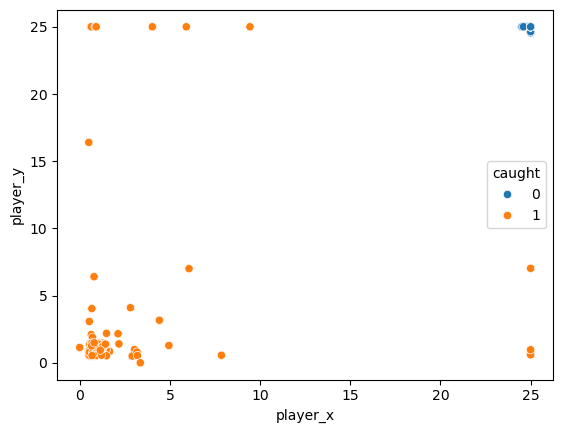

In [87]:
g = sns.scatterplot(
    data=df,
    x='player_x',
    y='player_y',
    hue='caught'
)

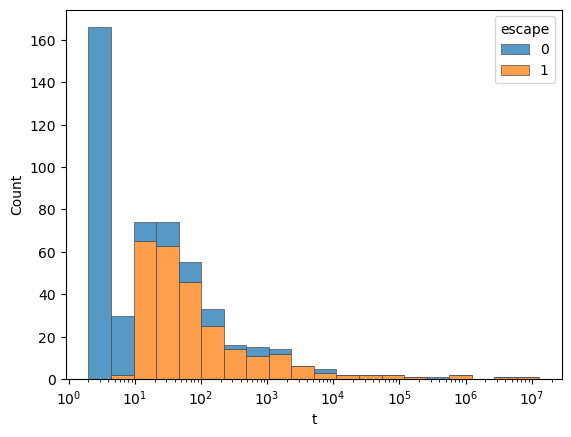

In [89]:
g1 = sns.histplot(
    data=df, 
    x='t',hue="escape",
    multiple="stack",
    edgecolor=".3",
    linewidth=.5,
    log_scale=True,
)